# Prepare the Pokemon Model

This notebook prepares the machine-learning resource used by the Streamlit prediction page. You will inspect the dataset, establish a simple baseline, train a Random Forest, interpret its limitations, and save a trusted local model. The objective is not to optimize a production classifier, but to understand what the app is loading and what its output can support.

```mermaid
flowchart LR
    A[Pokemon CSV] --> B[Explore and validate]
    B --> C[Train and evaluate]
    C --> D[Save model]
    D --> E[Streamlit prediction page]
```

## Imports and data

Pandas handles the table, seaborn and Matplotlib provide quick visual checks, and scikit-learn supplies the baseline, classifier, and evaluation metrics.

In [ ]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
)
from sklearn.model_selection import train_test_split

pd.options.display.max_columns = None

In [2]:
df = pd.read_csv("data/pokemon.csv")
df.head()

,pokedex_number,generation,name,classification,type,height_m,weight_kg,attack,defense,hit_points,sp_attack,sp_defense,speed,is_legendary,latitude,longitude
0,1,1,Bulbasaur,Seed Pokémon,grass,0.7,6.9,49,49,45,65,65,45,0,36.176714,139.551736
1,2,1,Ivysaur,Seed Pokémon,grass,1.0,13.0,62,63,60,80,80,60,0,36.327689,141.213030
2,3,1,Venusaur,Seed Pokémon,grass,2.0,100.0,100,123,80,122,120,80,0,35.445847,139.455863
3,4,1,Charmander,Lizard Pokémon,fire,0.6,8.5,52,43,39,60,50,65,0,37.259213,140.457435
4,5,1,Charmeleon,Flame Pokémon,fire,1.1,19.0,64,58,58,80,65,80,0,35.210526,140.232560


## Understand the dataset

Each row represents one Pokemon. The app predicts `is_legendary` from six battle statistics:

| Column | Meaning |
| --- | --- |
| `hit_points` | Capacity to absorb damage |
| `attack`, `defense` | Physical offensive and defensive strength |
| `sp_attack`, `sp_defense` | Special offensive and defensive strength |
| `speed` | Relative action speed |
| `is_legendary` | Binary target: 1 for legendary, 0 otherwise |

Names, types, dimensions, and coordinates remain available for exploration, but are deliberately excluded from this compact prediction interface.

In [3]:
quality_summary = pd.Series(
    {
        "rows": len(df),
        "columns": df.shape[1],
        "missing_values": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
    },
    name="value",
)
quality_summary

rows              801
columns            16
missing_values     40
duplicate_rows      0
Name: value, dtype: int64

## Inspect the target imbalance

Legendary Pokemon are rare. A classifier that always predicts the majority class can therefore achieve high ordinary accuracy while never finding a legendary example. Keep that imbalance in mind when evaluating the model.

In [4]:
target_summary = (
    df["is_legendary"].value_counts().rename_axis("is_legendary").to_frame("count")
)
target_summary["share"] = target_summary["count"] / len(df)
target_summary

,count,share
is_legendary,,
0,731,0.912609
1,70,0.087391


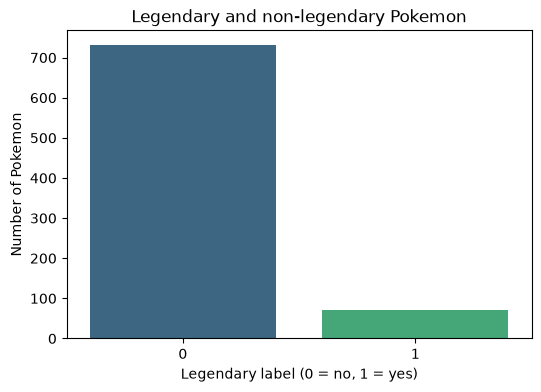

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(
    data=df,
    x="is_legendary",
    hue="is_legendary",
    palette="viridis",
    legend=False,
)
plt.title("Legendary and non-legendary Pokemon")
plt.xlabel("Legendary label (0 = no, 1 = yes)")
plt.ylabel("Number of Pokemon")
plt.show()

## Explore the model features

Check the feature ranges before creating widgets. The app should accept realistic values and pass the columns to the model in the same order used during training.

In [6]:
stats_cols = [
    "hit_points",
    "attack",
    "defense",
    "sp_attack",
    "sp_defense",
    "speed",
]

df[stats_cols].agg(["min", "median", "max"]).T

,min,median,max
hit_points,1.0,65.0,255.0
attack,5.0,75.0,185.0
defense,5.0,70.0,230.0
sp_attack,10.0,65.0,194.0
sp_defense,20.0,66.0,230.0
speed,5.0,65.0,180.0


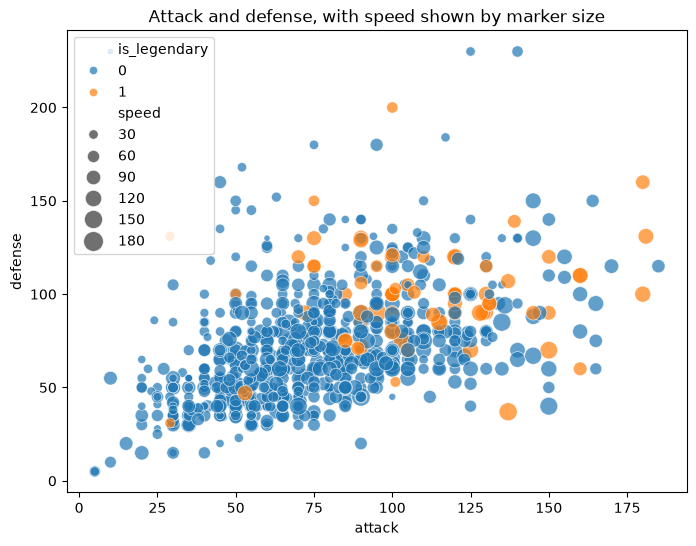

In [7]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df,
    x="attack",
    y="defense",
    hue="is_legendary",
    size="speed",
    sizes=(20, 200),
    alpha=0.7,
)
plt.title("Attack and defense, with speed shown by marker size")
plt.show()

A radar chart previews one visualisation that can later appear in the app. A fixed maximum keeps the scale comparable when a user selects another Pokemon.

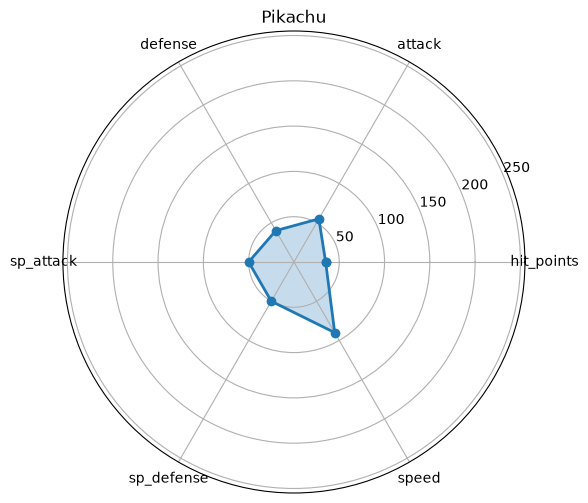

In [8]:
radar_max = df[stats_cols].max().max()


def plot_radar(pokemon_row):
    """Plot one Pokemon on a fixed scale for honest comparisons."""
    stats = pokemon_row[stats_cols].to_numpy()
    angles = np.linspace(0, 2 * np.pi, len(stats_cols), endpoint=False).tolist()
    closed_stats = np.append(stats, stats[0])
    closed_angles = angles + angles[:1]

    _, ax = plt.subplots(figsize=(6, 6), subplot_kw={"polar": True})
    ax.plot(closed_angles, closed_stats, "o-", linewidth=2)
    ax.fill(closed_angles, closed_stats, alpha=0.25)
    ax.set_xticks(angles, stats_cols)
    ax.set_ylim(0, radar_max)
    ax.set_title(pokemon_row["name"])
    plt.show()


pikachu = df.loc[df["name"] == "Pikachu"].iloc[0]
plot_radar(pikachu)

## How a Random Forest combines trees

A Random Forest trains many decision trees on different bootstrap samples and aggregates their votes. This reduces dependence on any single tree, but it does not remove bias in the data or guarantee reliable probabilities.

![Random Forest bootstrap sampling, trees, and aggregation](assets/random-forest-bagging.png)

*Source: [Harry585, Random Forest Bagging Illustration](https://commons.wikimedia.org/wiki/File:Random_Forest_Bagging_Illustration.png), [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).*

## Compare a baseline with the classifier

The stratified split preserves the target proportion in both sets. The dummy baseline always predicts the most frequent class; it provides the minimum behavior the Random Forest must improve upon. The same random seed keeps this teaching demonstration reproducible.

In [9]:
X = df[stats_cols]
y = df["is_legendary"]

random_seed = 33
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=random_seed,
    stratify=y,
)

baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

model = RandomForestClassifier(n_estimators=100, random_state=random_seed)
model.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)
model_pred = model.predict(X_test)

## Evaluate the result

Ordinary accuracy rewards correct predictions on the dominant class. Balanced accuracy gives equal weight to both classes. The classification report and confusion matrix then show which errors are hidden inside a single score.

In [10]:
evaluation = pd.DataFrame(
    {
        "accuracy": [
            accuracy_score(y_test, baseline_pred),
            accuracy_score(y_test, model_pred),
        ],
        "balanced_accuracy": [
            balanced_accuracy_score(y_test, baseline_pred),
            balanced_accuracy_score(y_test, model_pred),
        ],
    },
    index=["Dummy baseline", "Random Forest"],
)
evaluation.round(3)

,accuracy,balanced_accuracy
Dummy baseline,0.913,0.500
Random Forest,0.925,0.636


              precision    recall  f1-score   support

           0       0.94      0.99      0.96       147
           1       0.67      0.29      0.40        14

    accuracy                           0.93       161
   macro avg       0.80      0.64      0.68       161
weighted avg       0.91      0.93      0.91       161



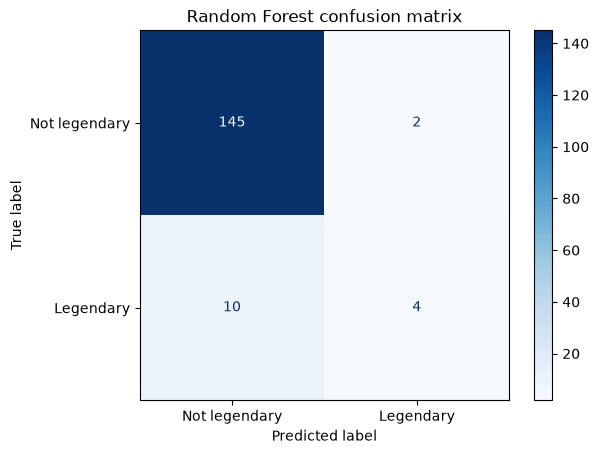

In [11]:
print(classification_report(y_test, model_pred, zero_division=0))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    model_pred,
    display_labels=["Not legendary", "Legendary"],
    cmap="Blues",
)
plt.title("Random Forest confusion matrix")
plt.show()

Focus on recall for the legendary class: it measures how many actual legendary examples the model finds. The model improves substantially over the baseline, but still misses several rare examples. Its output is suitable for demonstrating an interactive ML interface, not for making a consequential decision.

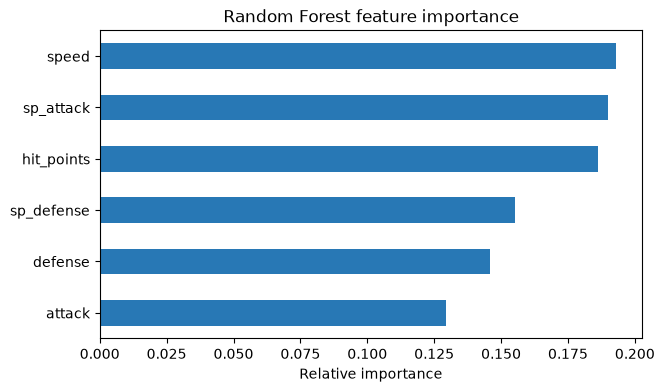

In [12]:
feature_importance = pd.Series(
    model.feature_importances_,
    index=stats_cols,
).sort_values()

ax = feature_importance.plot.barh(figsize=(7, 4), color="#2878B5")
ax.set_title("Random Forest feature importance")
ax.set_xlabel("Relative importance")
plt.show()

Feature importance describes how this fitted model used the available variables; it does not establish that a statistic causes a Pokemon to be legendary. Likewise, `predict_proba` expresses the model's confidence under its training assumptions. These probabilities have not been calibrated or validated for real-world decisions.

## Save and verify the local model

The prediction helper expects `models/random_forest.pkl` and passes columns in the order defined by `stats_cols`. Only load pickle files that you created or obtained from a trusted source.

In [13]:
model_path = Path("models/random_forest.pkl")
model_path.parent.mkdir(exist_ok=True)

with model_path.open("wb") as model_file:
    pickle.dump(model, model_file)

with model_path.open("rb") as model_file:
    reloaded_model = pickle.load(model_file)

assert list(reloaded_model.feature_names_in_) == stats_cols
preview_probabilities = reloaded_model.predict_proba(X_test.iloc[:3])[:, 1]

print(f"Saved and reloaded: {model_path.resolve()}")
pd.DataFrame(
    {
        "actual_label": y_test.iloc[:3].to_numpy(),
        "legendary_probability": preview_probabilities,
    }
).round(3)

Saved and reloaded: /home/priya/neuefische/exercises/aipm-streamlit/models/random_forest.pkl


,actual_label,legendary_probability
0,0,0.00
1,1,0.03
2,0,0.00


## Check your understanding

<details><summary>Why is ordinary accuracy misleading here?</summary>

Most Pokemon are not legendary, so a model can score highly by predicting only the majority class. Balanced accuracy and class-specific recall reveal that failure.

</details>

<details><summary>Why must the application preserve the feature order?</summary>

The fitted model associates each input column with a learned role. Reordering unnamed values could make an attack value appear where defense is expected and silently corrupt the prediction.

</details>

<details><summary>What does a probability of 80% mean in this app?</summary>

It is the Random Forest's output for the supplied values, based on this dataset and training procedure. It is not proof, a causal statement, or a calibrated real-world guarantee.

</details>

The model file is now ready. Continue with [Build the Streamlit App](03-build-the-streamlit-app.md).